# Running Bifurcation Analysis on the 5.2 Dynamical Toy Microbial Community

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.ticker import MultipleLocator

In [4]:
#  Configuration Variables 
n_conditions_plot = 1
media_val_plot = -11 # only change if n_conditions_plot = 1
n_params_plot = 1000
lag = 500 # max 500, min 1
show_what_plots = 4 # 1 = just bifurc, 2 = bifurc and period, 3 = bifurc & iters to converge, 4 = all

#  Parse Logs 
all_or_zoomed = "all" # or "zoomed"
log_paths = [f"./data/{all_or_zoomed}_logs/chaos_log{i}.tsv" for i in range(1, 101)]

all_rel_abunds, all_media_vals, all_periods, all_iters_converged = [], [], [], []
all_bio0_fluxes, all_bio1_fluxes, all_b_fluxes = [], [], []

for path in log_paths:
    with open(path) as f:
        r = csv.reader(f, delimiter="\t")
        next(r) # skip header
        for row in r:
            all_rel_abunds.append([float(x) for x in row[0].split(",")])
            all_media_vals.append(float(row[1]))
            all_periods.append(int(row[2]) if row[2] else None)
            all_iters_converged.append(int(row[3]) if row[3] else None)
            all_bio0_fluxes.append([float(x) for x in row[4].split(",")][-lag:])
            all_bio1_fluxes.append([float(x) for x in row[5].split(",")][-lag:])
            all_b_fluxes.append([float(x) for x in row[6].split(",")][-lag:])

#  Convert to Numpy Arrays 
all_rel_abunds = np.array(all_rel_abunds)
all_bio0_fluxes = np.array(all_bio0_fluxes)
all_bio1_fluxes = np.array(all_bio1_fluxes)
all_b_fluxes = np.array(all_b_fluxes)
all_periods = np.array(all_periods)
all_iters_converged = np.array(all_iters_converged)
all_media_vals = np.array(all_media_vals)

# Repeat each rel_abund for each flux point
all_rel_abunds = np.tile(all_rel_abunds[:, 0].reshape(-1, 1), reps=(1, all_bio0_fluxes.shape[1])) 

unique_media_vals = np.unique(all_media_vals)
media_vmin, media_vmax = -12, -9
media_norm = Normalize(vmin=media_vmin, vmax=media_vmax)

print(f"Loaded {len(log_paths)} logs. Unique media vals: {unique_media_vals}")

# Filtering and Masking 
# To use different selections, uncomment the desired media_idxs line below:
# media_idxs = np.arange(len(unique_media_vals)) # Plot all
# media_idxs = np.linspace(0, len(np.unique(all_media_vals))-1, n_conditions_plot, dtype=int)
media_idxs = np.where(np.unique(all_media_vals) == media_val_plot)[0]

media_to_plot = unique_media_vals[media_idxs]
media_mask = np.isin(all_media_vals, media_to_plot)

# Subset of all rel_abunds to plot
param_idxs = np.linspace(0, len(np.unique(all_rel_abunds[:,0]))-1, n_params_plot, dtype=int)
params_to_plot = np.unique(all_rel_abunds[:,0])[param_idxs]
param_mask = np.isin(all_rel_abunds[:,0], params_to_plot)

plot_mask = media_mask & param_mask

# Resample data
media_vals_plotted = all_media_vals[plot_mask]
rel_abunds_plotted = all_rel_abunds[plot_mask]
b_fluxes_plotted = all_b_fluxes[plot_mask]
periods_plotted = all_periods[plot_mask]
iters_converged_plotted = all_iters_converged[plot_mask]

#  Prepare Formatting for Scatter Plots
y_vals = b_fluxes_plotted.flatten()
x_vals = rel_abunds_plotted.flatten()
x1_2_vals = rel_abunds_plotted[:,0] 

# Maintain color values based on plotting mode
if len(media_idxs) == len(unique_media_vals):
    color_vals = np.repeat(media_vals_plotted, rel_abunds_plotted.shape[1])
    c1_2_vals = media_vals_plotted
elif len(media_idxs) == 1:
    color_vals = np.repeat(media_to_plot, rel_abunds_plotted.shape[0]*rel_abunds_plotted.shape[1])
    c1_2_vals = np.repeat(media_to_plot, rel_abunds_plotted.shape[0])
else:
    color_vals = np.repeat(media_vals_plotted, rel_abunds_plotted.shape[1])
    c1_2_vals = media_vals_plotted

Loaded 100 logs. Unique media vals: [-12.         -11.66666667 -11.33333333 -11.         -10.66666667
 -10.33333333 -10.          -9.66666667  -9.33333333  -9.        ]


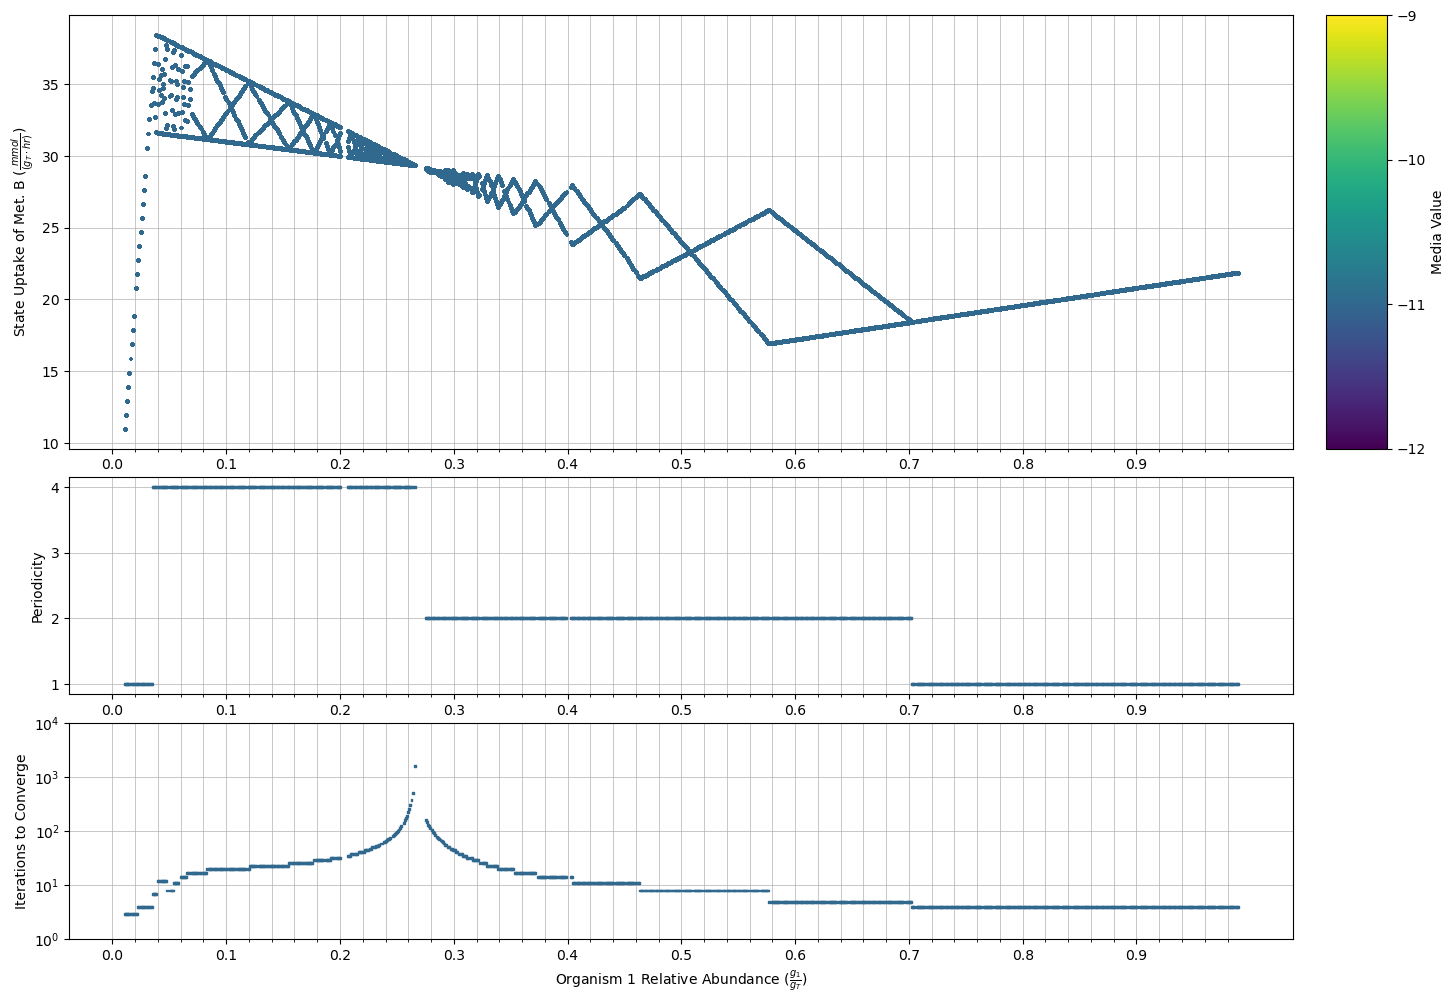

In [5]:
# --- Configure Layout Based on User Selection ---
if show_what_plots == 1:
    available_plots = ['flux']
    plots_label = "1"
elif show_what_plots == 2:
    available_plots = ['flux', 'periods']
    plots_label = "12"
elif show_what_plots == 3:
    available_plots = ['flux', 'iters']
    plots_label = "13"
else: 
    available_plots = ['flux', 'periods', 'iters']
    plots_label = "123"

# Build media label and filename
if len(media_idxs) == len(unique_media_vals):
    media_label = 'mediaAll'
elif len(media_idxs) == 1:
    media_label = f"media{int(np.abs(media_to_plot[0]))}"
else:
    media_label = f"mediaSubset{len(media_to_plot)}"

filename = f"../../../figures/toy_model_figs/supplement/UptakeB_vs_a0_plots{plots_label}_{media_label}_{all_or_zoomed}.png"

# Figure and GridSpec Setup
if len(available_plots) == 1:
    width = 8
elif len(available_plots) == 2:
    width = 12  
else:
    width = 17

fig = plt.figure(figsize=(width, 4 * len(available_plots)), clear=True)
nrows = len(available_plots)    
height_ratios = [2 if p == 'flux' else 1 for p in available_plots]
width_ratios = [20, 1] 

gs = gridspec.GridSpec(nrows, 2, width_ratios=width_ratios, height_ratios=height_ratios, wspace=0.05, hspace=0.1)

axes = []
for i in range(nrows):
    ax = fig.add_subplot(gs[i, 0]) if i == 0 else fig.add_subplot(gs[i, 0], sharex=axes[0])
    axes.append(ax)

cax = fig.add_subplot(gs[0, 1])

# Grid Lines & Ticks
major_x_ticks = np.arange(0, 1, 0.1) 
minor_x_ticks = np.arange(0, 1, 0.02)
period_y_ticks = [1, 2, 3, 4]
iters_y_ticks = np.logspace(0, 4, 5) # 1, 10, 100, 1000

# Plotting Loop
sc = None
for i, p in enumerate(available_plots):
    ax = axes[i]
    if p == 'flux':
        sc = ax.scatter(x_vals, y_vals, c=color_vals, cmap='viridis', norm=media_norm, s=2, marker='s', zorder=3)
        ax.set_ylabel(r'State Uptake of Met. B ($\frac{mmol}{(g_T \cdot hr)}$)')
        ax.set_xticks(major_x_ticks)
        ax.set_xticks(minor_x_ticks, minor=True)
        ax.grid(which='both', linewidth=0.5, zorder=0)
    elif p == 'periods':
        ax.scatter(x1_2_vals, periods_plotted.flatten(), c=c1_2_vals, cmap='viridis', norm=media_norm, s=2, marker='s', zorder=3)
        ax.set_ylabel('Periodicity')
        ax.set_xticks(major_x_ticks)
        ax.set_xticks(minor_x_ticks, minor=True)
        ax.set_yticks(period_y_ticks)
        ax.grid(which='both', linewidth=0.5, zorder=0)
    elif p == 'iters':
        ax.scatter(x1_2_vals, iters_converged_plotted.flatten(), c=c1_2_vals, cmap='viridis', norm=media_norm, s=2, marker='s', zorder=3)
        ax.set_yscale('log')
        ax.set_ylabel('Iterations to Converge')
        ax.set_xticks(major_x_ticks)
        ax.set_xticks(minor_x_ticks, minor=True)
        ax.set_yticks(iters_y_ticks)
        ax.set_yticks([], minor=True)
        ax.grid(which='both', linewidth=0.5, zorder=0)
        
    if i == nrows - 1:
        ax.set_xlabel(r'Organism 1 Relative Abundance ($\frac{g_1}{g_T}$)')

cb = plt.colorbar(sc, cax=cax)
cb.set_label('Media Value')
cb.set_ticks(np.arange(media_vmin, media_vmax+1, 1))

plt.savefig(filename)
plt.show() # Added to render output inside the Jupyter Notebook cell